# Imports & SetUp

In [1]:
import os
import copy
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import utils, transforms, datasets
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
from paths_setup import TRAIN_DIR, TEST_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")

In [6]:
VIEW_CLASS = ["02", "06", "08", "12", "13", "14", "15", "16", "18", "21", "22", "23", "27", "30"]

missing_train = [c for c in VIEW_CLASS if not (TRAIN_DIR / c).exists()]
missing_test  = [c for c in VIEW_CLASS if not (TEST_DIR  / c).exists()]

if missing_train:
    raise FileNotFoundError(f"Missing train class folders: {missing_train}")
if missing_test:
    raise FileNotFoundError(f"Missing test class folders: {missing_test}")

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 8

# Data Exploration

## General Information

In [9]:
def show_first_10_images(folder_dir: Path, view_name: str) -> None:
    
    view_dir = Path(folder_dir) / view_name
    png_files = sorted(view_dir.glob("*.png"))[:10]

    if not view_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {view_dir}")

    if len(png_files) == 0:
        raise FileNotFoundError(f"No PNG files found in: {view_dir}")

    n = len(png_files)
    rows, cols = 2, 5

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.axis("off")

        if i < n:
            img = Image.open(png_files[i])
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "EMPTY", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [10]:
def count_pngs(folder: Path) -> int:
    
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png")

In [11]:
def print_view_image_counts(view_name: str) -> Tuple[int, int]:

    view_name = str(view_name).strip()
    
    train_view_dir = TRAIN_DIR / view_name
    test_view_dir  = TEST_DIR / view_name

    train_count = count_pngs(train_view_dir)
    test_count  = count_pngs(test_view_dir)

    return train_count, test_count

In [12]:
total_train = 0
total_test  = 0
counts_matrix = []

print(f"--- Data Summary ---")

for vc in VIEW_CLASS:
    temp_train, temp_test = print_view_image_counts(vc)

    counts_matrix.append([temp_train, temp_test])
    
    total_train += temp_train
    total_test  += temp_test
    
    print(f"View {vc}: {temp_train + temp_test} images ({temp_train} train images; {temp_test} test images)")
    
print(f"Total: {total_train + total_test} images ({total_train} train images; {total_test} test images)")

--- Data Summary ---
View 02: 19566 images (15317 train images; 4249 test images)
View 06: 10401 images (10000 train images; 401 test images)
View 08: 13020 images (10272 train images; 2748 test images)
View 12: 22663 images (18030 train images; 4633 test images)
View 13: 17814 images (14385 train images; 3429 test images)
View 14: 11139 images (10000 train images; 1139 test images)
View 15: 31473 images (25052 train images; 6421 test images)
View 16: 12061 images (10000 train images; 2061 test images)
View 18: 11058 images (10000 train images; 1058 test images)
View 21: 14059 images (11160 train images; 2899 test images)
View 22: 10895 images (10000 train images; 895 test images)
View 23: 13723 images (10930 train images; 2793 test images)
View 27: 11670 images (10000 train images; 1670 test images)
View 30: 10803 images (10000 train images; 803 test images)
Total: 210345 images (175146 train images; 35199 test images)


In [13]:
def plot_train_test_counts_stacked(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))

    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", label="Train")
    plt.bar(x, test_counts,  width=0.80, color="C1", label="Test", bottom=train_counts)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train + Test)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
def plot_train_test_counts_overlaid(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))
    
    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", alpha=0.5, label="Train", zorder=1)
    plt.bar(x, test_counts,  width=0.80, color="C1", alpha=0.5, label="Test",  zorder=2)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train and Test - Overlaid)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

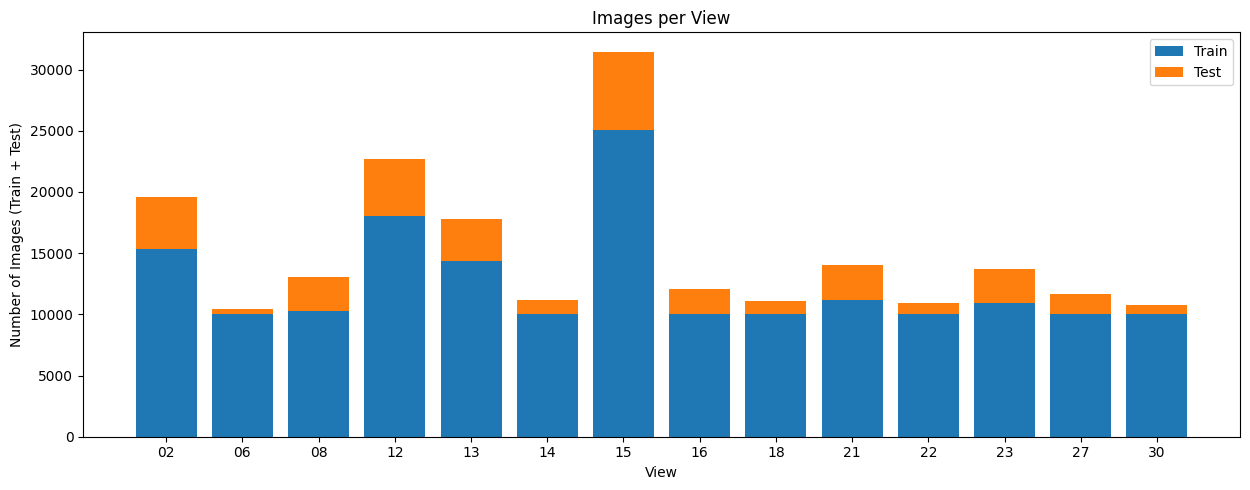

In [15]:
plot_train_test_counts_stacked(VIEW_CLASS, counts_matrix)

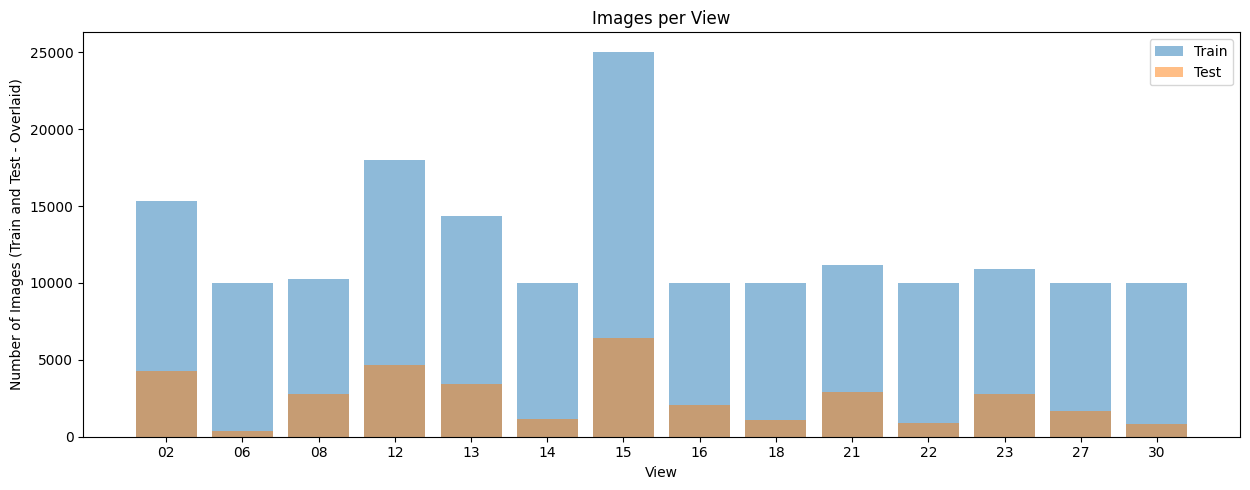

In [16]:
plot_train_test_counts_overlaid(VIEW_CLASS, counts_matrix)

## Label Mapping

In [17]:
class_to_idx = {name: i for i, name in enumerate(VIEW_CLASS)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print("Label mapping:")
for k in sorted(class_to_idx.keys()):
    print(f"   {k} -> {class_to_idx[k]}")

Label mapping:
   02 -> 0
   06 -> 1
   08 -> 2
   12 -> 3
   13 -> 4
   14 -> 5
   15 -> 6
   16 -> 7
   18 -> 8
   21 -> 9
   22 -> 10
   23 -> 11
   27 -> 12
   30 -> 13


## Check Image Size Consistency

In [18]:
EXCLUDED_FILES = []

def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.append(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [19]:
verify_image_dimensions(TRAIN_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/train:

   View 02:
      Mismatch found: __Amy__DicomIMG_ID_69214103__20200810140438__1.png is (432, 288)
      Mismatch found: __DCM__DicomIMG_ID_60302307__nk095938.000000__1.png is (432, 288)

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found



In [20]:
verify_image_dimensions(TEST_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/test:

   View 02:
      No mismatches found

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found

Success: All images are confirmed to be (224, 224)


In [21]:
print(f"Files to exclude: {EXCLUDED_FILES}")

Files to exclude: ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']


## View 02

In [ ]:
show_first_10_images(TRAIN_DIR, "02")
show_first_10_images(TEST_DIR,  "02")

## View 06

In [ ]:
show_first_10_images(TRAIN_DIR, "06")
show_first_10_images(TEST_DIR,  "06")

## View 08

In [ ]:
show_first_10_images(TRAIN_DIR, "08")
show_first_10_images(TEST_DIR,  "08")

## View 12

In [ ]:
show_first_10_images(TRAIN_DIR, "12")
show_first_10_images(TEST_DIR,  "12")

## View 13

In [ ]:
show_first_10_images(TRAIN_DIR, "13")
show_first_10_images(TEST_DIR,  "13")

## View 14

In [ ]:
show_first_10_images(TRAIN_DIR, "14")
show_first_10_images(TEST_DIR,  "14")

## View 15

In [ ]:
show_first_10_images(TRAIN_DIR, "15")
show_first_10_images(TEST_DIR,  "15")

## View 16

In [ ]:
show_first_10_images(TRAIN_DIR, "16")
show_first_10_images(TEST_DIR,  "16")

## View 18

In [ ]:
show_first_10_images(TRAIN_DIR, "18")
show_first_10_images(TEST_DIR,  "18")

## View 21

In [ ]:
show_first_10_images(TRAIN_DIR, "21")
show_first_10_images(TEST_DIR,  "21")

## View 22

In [ ]:
show_first_10_images(TRAIN_DIR, "22")
show_first_10_images(TEST_DIR,  "22")

## View 23

In [ ]:
show_first_10_images(TRAIN_DIR, "23")
show_first_10_images(TEST_DIR,  "23")

## View 27

In [ ]:
show_first_10_images(TRAIN_DIR, "27")
show_first_10_images(TEST_DIR,  "27")

## View 30

In [ ]:
show_first_10_images(TRAIN_DIR, "30")
show_first_10_images(TEST_DIR,  "30")

# Data Preprocessing

## Data Transforms

In [22]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [23]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [24]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [25]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [26]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size: ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size: ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:  140115
Validation set size:  35029
Test set size:  35199


## Class Weights

In [27]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [28]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


## Data Loaders

In [29]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    
    print(f"Batch shape: {images.shape}")
    
    plt.figure(figsize=(16, 8))
    
    images = images * 0.5 + 0.5 
    
    grid_img = utils.make_grid(images, nrow=8, padding=2)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
    plt.axis('off')
    plt.title("Batch of Preprocessed Training Images (Grayscale)")
    plt.show()

show_batch(train_loader)